<a href="https://colab.research.google.com/github/rahulsanjel/BigData/blob/main/6CS030_BigData_BankMarketing_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS030 Big Data Project
## Predicting Bank Term Deposit Subscriptions Using Apache Spark MLlib
**Dataset:** UCI Bank Marketing Additional Dataset (`bank-additional-full.csv`)  
**Tools:** PySpark, Spark SQL, Spark MLlib, Matplotlib


---
## 1. Environment Setup & SparkSession Initialisation

In [ ]:
# Install PySpark if running in a fresh environment (e.g., Google Colab)
# !pip install pyspark

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType, DoubleType, StringType

# ML Libraries
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
)
from pyspark.ml.classification import (
    LogisticRegression, RandomForestClassifier, GBTClassifier
)
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Initialise SparkSession
spark = SparkSession.builder \
    .appName("6CS030_BankMarketing_BigData") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f"Spark Version: {spark.version}")
print(f"Spark UI: {spark.sparkContext.uiWebUrl}")

Spark Version: 4.0.2
Spark UI: http://4e50286d7546:4040


---
## 2. Data Acquisition — Load into Spark DataFrame

In [ ]:
# -----------------------------------------------------------------------
# Download dataset from UCI repository
# -----------------------------------------------------------------------
import urllib.request, zipfile, os

DATA_URL  = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"
ZIP_PATH  = "bank-additional.zip"
CSV_FILE  = "bank-additional/bank-additional-full.csv"

if not os.path.exists(CSV_FILE):
    print("Downloading dataset ...")
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(".")
    print("Download complete.")
else:
    print("Dataset already present.")

Download complete.


In [ ]:
# -----------------------------------------------------------------------
# Load CSV into Spark DataFrame (semicolon-delimited, header row)
# -----------------------------------------------------------------------
raw_df = spark.read.csv(
    CSV_FILE,
    header=True,
    inferSchema=True,
    sep=";"
)

print(f"Records loaded : {raw_df.count():,}")
print(f"Columns        : {len(raw_df.columns)}")
raw_df.printSchema()

Records loaded : 41,188
Columns        : 21
root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- month: string (nullable = true)
 |-- day_of_week: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- emp.var.rate: double (nullable = true)
 |-- cons.price.idx: double (nullable = true)
 |-- cons.conf.idx: double (nullable = true)
 |-- euribor3m: double (nullable = true)
 |-- nr.employed: double (nullable = true)
 |-- y: string (nullable = true)



In [ ]:
# Quick peek at the first 5 rows
raw_df.show(5, truncate=False)

+---+---------+-------+-----------+-------+-------+----+---------+-----+-----------+--------+--------+-----+--------+-----------+------------+--------------+-------------+---------+-----------+---+
|age|job      |marital|education  |default|housing|loan|contact  |month|day_of_week|duration|campaign|pdays|previous|poutcome   |emp.var.rate|cons.price.idx|cons.conf.idx|euribor3m|nr.employed|y  |
+---+---------+-------+-----------+-------+-------+----+---------+-----+-----------+--------+--------+-----+--------+-----------+------------+--------------+-------------+---------+-----------+---+
|56 |housemaid|married|basic.4y   |no     |no     |no  |telephone|may  |mon        |261     |1       |999  |0       |nonexistent|1.1         |93.994        |-36.4        |4.857    |5191.0     |no |
|57 |services |married|high.school|unknown|no     |no  |telephone|may  |mon        |149     |1       |999  |0       |nonexistent|1.1         |93.994        |-36.4        |4.857    |5191.0     |no |
|37 |servi

---
## 3. Data Cleaning — Spark SQL Approach
### 3.1 Register as a Temporary View

In [ ]:
# Register as SQL temporary view
raw_df.createOrReplaceTempView("bank_raw")
print("Temporary view 'bank_raw' registered.")

Temporary view 'bank_raw' registered.


### 3.2 Inspect Null & 'unknown' Values via SQL

In [ ]:
# Count nulls across all columns using Spark SQL
null_check_sql = """
SELECT
    SUM(CASE WHEN age       IS NULL THEN 1 ELSE 0 END) AS age_nulls,
    SUM(CASE WHEN job       IS NULL THEN 1 ELSE 0 END) AS job_nulls,
    SUM(CASE WHEN marital   IS NULL THEN 1 ELSE 0 END) AS marital_nulls,
    SUM(CASE WHEN education IS NULL THEN 1 ELSE 0 END) AS education_nulls,
    SUM(CASE WHEN `default` IS NULL THEN 1 ELSE 0 END) AS default_nulls,
    SUM(CASE WHEN housing   IS NULL THEN 1 ELSE 0 END) AS housing_nulls,
    SUM(CASE WHEN loan      IS NULL THEN 1 ELSE 0 END) AS loan_nulls,
    SUM(CASE WHEN contact   IS NULL THEN 1 ELSE 0 END) AS contact_nulls,
    SUM(CASE WHEN duration  IS NULL THEN 1 ELSE 0 END) AS duration_nulls,
    SUM(CASE WHEN campaign  IS NULL THEN 1 ELSE 0 END) AS campaign_nulls,
    SUM(CASE WHEN pdays     IS NULL THEN 1 ELSE 0 END) AS pdays_nulls,
    SUM(CASE WHEN previous  IS NULL THEN 1 ELSE 0 END) AS previous_nulls,
    SUM(CASE WHEN poutcome  IS NULL THEN 1 ELSE 0 END) AS poutcome_nulls,
    SUM(CASE WHEN y         IS NULL THEN 1 ELSE 0 END) AS y_nulls
FROM bank_raw
"""
spark.sql(null_check_sql).show()

+---------+---------+-------------+---------------+-------------+-------------+----------+-------------+--------------+--------------+-----------+--------------+--------------+-------+
|age_nulls|job_nulls|marital_nulls|education_nulls|default_nulls|housing_nulls|loan_nulls|contact_nulls|duration_nulls|campaign_nulls|pdays_nulls|previous_nulls|poutcome_nulls|y_nulls|
+---------+---------+-------------+---------------+-------------+-------------+----------+-------------+--------------+--------------+-----------+--------------+--------------+-------+
|        0|        0|            0|              0|            0|            0|         0|            0|             0|             0|          0|             0|             0|      0|
+---------+---------+-------------+---------------+-------------+-------------+----------+-------------+--------------+--------------+-----------+--------------+--------------+-------+



In [ ]:
# Count 'unknown' category values in key categorical columns
unknown_check_sql = """
SELECT
    SUM(CASE WHEN job       = 'unknown' THEN 1 ELSE 0 END) AS job_unknown,
    SUM(CASE WHEN marital   = 'unknown' THEN 1 ELSE 0 END) AS marital_unknown,
    SUM(CASE WHEN education = 'unknown' THEN 1 ELSE 0 END) AS education_unknown,
    SUM(CASE WHEN `default` = 'unknown' THEN 1 ELSE 0 END) AS default_unknown,
    SUM(CASE WHEN housing   = 'unknown' THEN 1 ELSE 0 END) AS housing_unknown,
    SUM(CASE WHEN loan      = 'unknown' THEN 1 ELSE 0 END) AS loan_unknown
FROM bank_raw
"""
spark.sql(unknown_check_sql).show()

+-----------+---------------+-----------------+---------------+---------------+------------+
|job_unknown|marital_unknown|education_unknown|default_unknown|housing_unknown|loan_unknown|
+-----------+---------------+-----------------+---------------+---------------+------------+
|        330|             80|             1731|           8597|            990|         990|
+-----------+---------------+-----------------+---------------+---------------+------------+



### 3.3 Clean Data Using Spark SQL
Strategy:
- Replace `'unknown'` in categorical columns with the **mode** (most frequent value)
- Drop `duration` column (UCI note: duration=0 means call not made; leaks target)
- Cast types explicitly
- Filter out noisy `pdays=999` (no previous contact) — keep as flag instead
- Encode target `y`: yes→1, no→0

In [ ]:
# Compute modes for imputation using SQL
mode_sql = """
SELECT
    (SELECT job       FROM bank_raw WHERE job       != 'unknown' GROUP BY job       ORDER BY COUNT(*) DESC LIMIT 1) AS mode_job,
    (SELECT marital   FROM bank_raw WHERE marital   != 'unknown' GROUP BY marital   ORDER BY COUNT(*) DESC LIMIT 1) AS mode_marital,
    (SELECT education FROM bank_raw WHERE education != 'unknown' GROUP BY education ORDER BY COUNT(*) DESC LIMIT 1) AS mode_education,
    (SELECT `default` FROM bank_raw WHERE `default` != 'unknown' GROUP BY `default` ORDER BY COUNT(*) DESC LIMIT 1) AS mode_default,
    (SELECT housing   FROM bank_raw WHERE housing   != 'unknown' GROUP BY housing   ORDER BY COUNT(*) DESC LIMIT 1) AS mode_housing,
    (SELECT loan      FROM bank_raw WHERE loan      != 'unknown' GROUP BY loan      ORDER BY COUNT(*) DESC LIMIT 1) AS mode_loan
"""
modes = spark.sql(mode_sql).collect()[0]
print("Imputation modes:")
for col in modes.asDict():
    print(f"  {col}: {modes[col]}")

Imputation modes:
  mode_job: admin.
  mode_marital: married
  mode_education: university.degree
  mode_default: no
  mode_housing: yes
  mode_loan: no


In [ ]:
# Full Spark SQL cleaning query with fixed backticks for dot-notation columns
clean_sql = f"""
SELECT
    CAST(age AS INT)                                           AS age,
    CASE WHEN job = 'unknown' THEN '{modes.mode_job}'
         ELSE job END                                          AS job,
    CASE WHEN marital = 'unknown' THEN '{modes.mode_marital}'
         ELSE marital END                                      AS marital,
    CASE WHEN education = 'unknown' THEN '{modes.mode_education}'
         ELSE education END                                    AS education,
    CASE WHEN `default` = 'unknown' THEN '{modes.mode_default}'
         ELSE `default` END                                    AS credit_default,
    CASE WHEN housing = 'unknown' THEN '{modes.mode_housing}'
         ELSE housing END                                      AS housing,
    CASE WHEN loan = 'unknown' THEN '{modes.mode_loan}'
         ELSE loan END                                         AS loan,
    contact,
    month,
    day_of_week,
    CAST(campaign AS INT)                                      AS campaign,
    CASE WHEN pdays = 999 THEN 0 ELSE 1 END                    AS was_previously_contacted,
    CAST(previous AS INT)                                      AS previous,
    poutcome,
    CAST(`emp.var.rate` AS DOUBLE)                             AS emp_var_rate,
    CAST(`cons.price.idx` AS DOUBLE)                           AS cons_price_idx,
    CAST(`cons.conf.idx` AS DOUBLE)                            AS cons_conf_idx,
    CAST(euribor3m AS DOUBLE)                                  AS euribor3m,
    CAST(`nr.employed` AS DOUBLE)                              AS nr_employed,
    CASE WHEN y = 'yes' THEN 1 ELSE 0 END                      AS label
FROM bank_raw
WHERE campaign <= 30
"""

clean_df = spark.sql(clean_sql)
clean_df.createOrReplaceTempView("bank_clean")

print(f"Cleaned records : {clean_df.count():,}")
clean_df.printSchema()

Cleaned records : 41,155
root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- credit_default: string (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- month: string (nullable = true)
 |-- day_of_week: string (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- was_previously_contacted: integer (nullable = false)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- emp_var_rate: double (nullable = true)
 |-- cons_price_idx: double (nullable = true)
 |-- cons_conf_idx: double (nullable = true)
 |-- euribor3m: double (nullable = true)
 |-- nr_employed: double (nullable = true)
 |-- label: integer (nullable = false)



In [ ]:
clean_df.show(5, truncate=False)

+---+---------+-------+-----------+--------------+-------+----+---------+-----+-----------+--------+------------------------+--------+-----------+------------+--------------+-------------+---------+-----------+-----+
|age|job      |marital|education  |credit_default|housing|loan|contact  |month|day_of_week|campaign|was_previously_contacted|previous|poutcome   |emp_var_rate|cons_price_idx|cons_conf_idx|euribor3m|nr_employed|label|
+---+---------+-------+-----------+--------------+-------+----+---------+-----+-----------+--------+------------------------+--------+-----------+------------+--------------+-------------+---------+-----------+-----+
|56 |housemaid|married|basic.4y   |no            |no     |no  |telephone|may  |mon        |1       |0                       |0       |nonexistent|1.1         |93.994        |-36.4        |4.857    |5191.0     |0    |
|57 |services |married|high.school|no            |no     |no  |telephone|may  |mon        |1       |0                       |0      

---
## 4. Exploratory Data Analysis (EDA) via Spark SQL

In [ ]:
# 4.1 Target class distribution
target_dist = spark.sql("""
    SELECT
        CASE WHEN label = 1 THEN 'Yes (Subscribed)' ELSE 'No (Not Subscribed)' END AS outcome,
        COUNT(*) AS count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS percentage
    FROM bank_clean
    GROUP BY label
    ORDER BY label
""")
target_dist.show()

+-------------------+-----+----------+
|            outcome|count|percentage|
+-------------------+-----+----------+
|No (Not Subscribed)|36515|     88.73|
|   Yes (Subscribed)| 4640|     11.27|
+-------------------+-----+----------+



In [ ]:
# 4.2 Subscription rate by job category
job_analysis = spark.sql("""
    SELECT
        job,
        COUNT(*) AS total,
        SUM(label) AS subscribed,
        ROUND(SUM(label) * 100.0 / COUNT(*), 2) AS subscription_rate_pct
    FROM bank_clean
    GROUP BY job
    ORDER BY subscription_rate_pct DESC
""")
job_analysis.show(truncate=False)

+-------------+-----+----------+---------------------+
|job          |total|subscribed|subscription_rate_pct|
+-------------+-----+----------+---------------------+
|student      |875  |275       |31.43                |
|retired      |1719 |434       |25.25                |
|unemployed   |1014 |144       |14.20                |
|admin.       |10743|1389      |12.93                |
|management   |2922 |328       |11.23                |
|technician   |6736 |730       |10.84                |
|self-employed|1419 |149       |10.50                |
|housemaid    |1060 |106       |10.00                |
|entrepreneur |1455 |124       |8.52                 |
|services     |3965 |323       |8.15                 |
|blue-collar  |9247 |638       |6.90                 |
+-------------+-----+----------+---------------------+



In [ ]:
# 4.3 Subscription rate by month
month_analysis = spark.sql("""
    SELECT
        month,
        COUNT(*) AS total_contacts,
        SUM(label) AS subscribed,
        ROUND(SUM(label) * 100.0 / COUNT(*), 2) AS subscription_rate_pct
    FROM bank_clean
    GROUP BY month
    ORDER BY subscription_rate_pct DESC
""")
month_analysis.show()

+-----+--------------+----------+---------------------+
|month|total_contacts|subscribed|subscription_rate_pct|
+-----+--------------+----------+---------------------+
|  mar|           546|       276|                50.55|
|  dec|           182|        89|                48.90|
|  sep|           570|       256|                44.91|
|  oct|           718|       315|                43.87|
|  apr|          2632|       539|                20.48|
|  aug|          6178|       655|                10.60|
|  jun|          5308|       559|                10.53|
|  nov|          4101|       416|                10.14|
|  jul|          7157|       649|                 9.07|
|  may|         13763|       886|                 6.44|
+-----+--------------+----------+---------------------+



In [ ]:
# 4.4 Age statistics by outcome
age_stats = spark.sql("""
    SELECT
        CASE WHEN label = 1 THEN 'Subscribed' ELSE 'Not Subscribed' END AS outcome,
        ROUND(AVG(age), 2)    AS avg_age,
        MIN(age)              AS min_age,
        MAX(age)              AS max_age,
        ROUND(STDDEV(age), 2) AS std_age
    FROM bank_clean
    GROUP BY label
""")
age_stats.show()

+--------------+-------+-------+-------+-------+
|       outcome|avg_age|min_age|max_age|std_age|
+--------------+-------+-------+-------+-------+
|    Subscribed|  40.91|     17|     98|  13.84|
|Not Subscribed|  39.91|     17|     95|    9.9|
+--------------+-------+-------+-------+-------+



In [ ]:
# 4.5 Economic indicators by outcome
econ_analysis = spark.sql("""
    SELECT
        CASE WHEN label = 1 THEN 'Subscribed' ELSE 'Not Subscribed' END AS outcome,
        ROUND(AVG(emp_var_rate), 4)    AS avg_emp_var_rate,
        ROUND(AVG(cons_price_idx), 4)  AS avg_cons_price_idx,
        ROUND(AVG(euribor3m), 4)       AS avg_euribor3m,
        ROUND(AVG(nr_employed), 2)     AS avg_nr_employed
    FROM bank_clean
    GROUP BY label
""")
econ_analysis.show()

+--------------+----------------+------------------+-------------+---------------+
|       outcome|avg_emp_var_rate|avg_cons_price_idx|avg_euribor3m|avg_nr_employed|
+--------------+----------------+------------------+-------------+---------------+
|    Subscribed|         -1.2334|           93.3544|       2.1231|        5095.12|
|Not Subscribed|          0.2479|           93.6033|       3.8105|        5176.13|
+--------------+----------------+------------------+-------------+---------------+



---
## 5. Visualisations (from Spark Aggregations)

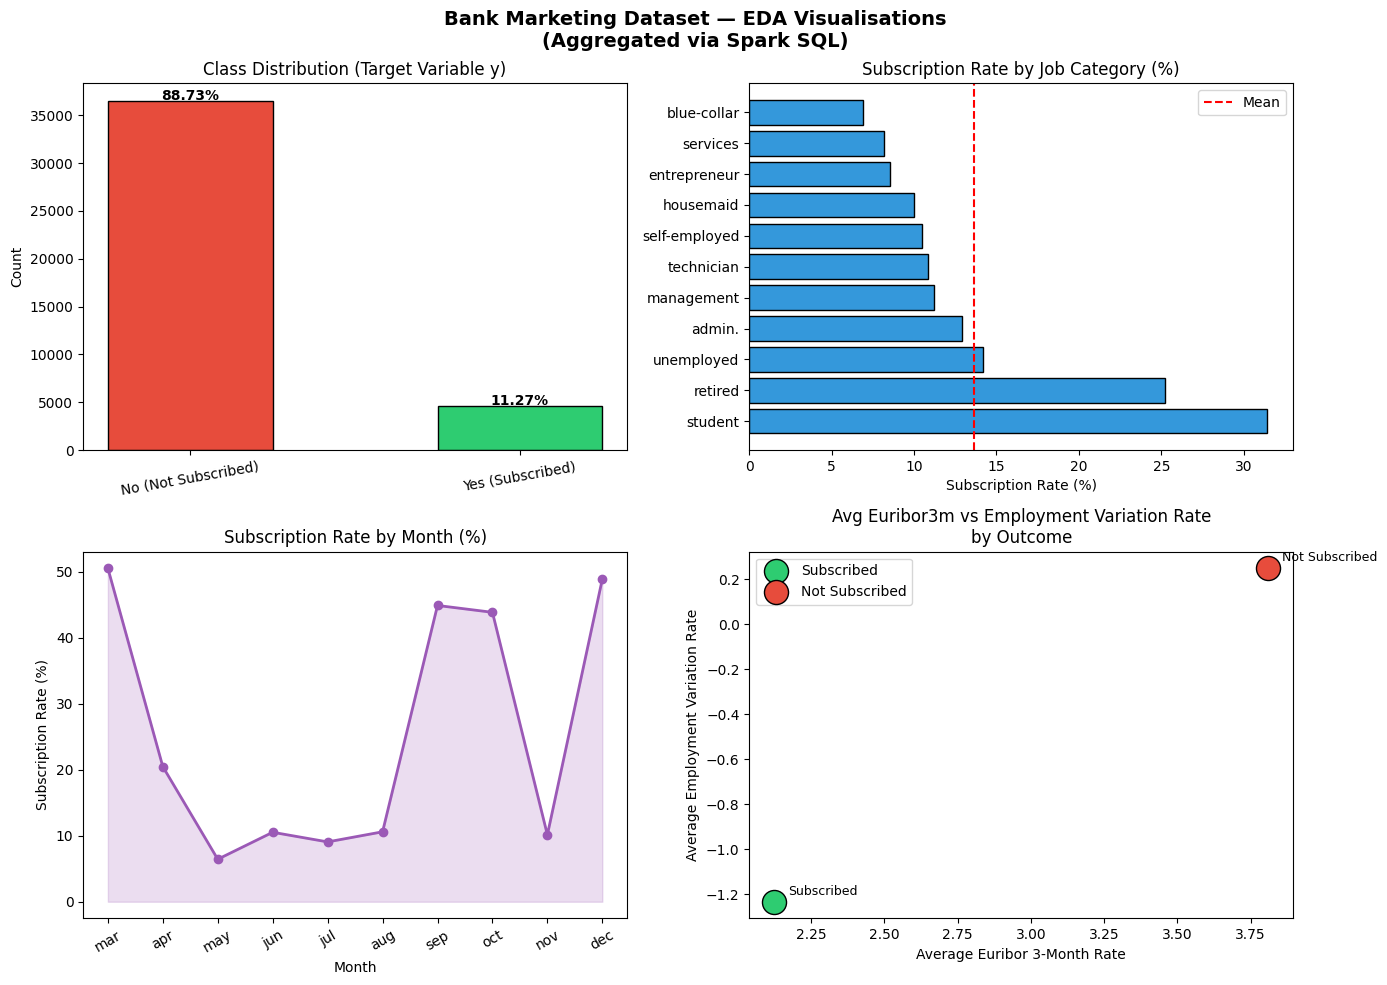

Figure saved as 'eda_visualisations.png'


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Bank Marketing Dataset — EDA Visualisations\n(Aggregated via Spark SQL)',
             fontsize=14, fontweight='bold')

# ---- Plot 1: Class Imbalance ----
td = target_dist.toPandas()
colors = ['#e74c3c', '#2ecc71']
axes[0,0].bar(td['outcome'], td['count'], color=colors, edgecolor='black', width=0.5)
for i, (cnt, pct) in enumerate(zip(td['count'], td['percentage'])):
    axes[0,0].text(i, cnt + 100, f'{pct}%', ha='center', fontweight='bold')
axes[0,0].set_title('Class Distribution (Target Variable y)')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=10)

# ---- Plot 2: Subscription Rate by Job ----
jd = job_analysis.toPandas()
bars = axes[0,1].barh(jd['job'], jd['subscription_rate_pct'], color='#3498db', edgecolor='black')
axes[0,1].set_title('Subscription Rate by Job Category (%)')
axes[0,1].set_xlabel('Subscription Rate (%)')
axes[0,1].axvline(x=jd['subscription_rate_pct'].mean(), color='red', linestyle='--', label='Mean')
axes[0,1].legend()

# ---- Plot 3: Subscription Rate by Month ----
md = month_analysis.toPandas()
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
md['month_num'] = md['month'].apply(lambda x: month_order.index(x) if x in month_order else 99)
md = md.sort_values('month_num')
axes[1,0].plot(md['month'], md['subscription_rate_pct'], marker='o', color='#9b59b6', linewidth=2)
axes[1,0].fill_between(range(len(md)), md['subscription_rate_pct'], alpha=0.2, color='#9b59b6')
axes[1,0].set_title('Subscription Rate by Month (%)')
axes[1,0].set_ylabel('Subscription Rate (%)')
axes[1,0].set_xlabel('Month')
axes[1,0].tick_params(axis='x', rotation=30)

# ---- Plot 4: Euribor vs Employment Rate ----
ed = econ_analysis.toPandas()
for _, row in ed.iterrows():
    color = '#2ecc71' if row['outcome'] == 'Subscribed' else '#e74c3c'
    axes[1,1].scatter(row['avg_euribor3m'], row['avg_emp_var_rate'],
                      color=color, s=300, edgecolors='black', zorder=5, label=row['outcome'])
    axes[1,1].annotate(row['outcome'], (row['avg_euribor3m'], row['avg_emp_var_rate']),
                       textcoords='offset points', xytext=(10, 5), fontsize=9)
axes[1,1].set_title('Avg Euribor3m vs Employment Variation Rate\nby Outcome')
axes[1,1].set_xlabel('Average Euribor 3-Month Rate')
axes[1,1].set_ylabel('Average Employment Variation Rate')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('eda_visualisations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as 'eda_visualisations.png'")

---
## 6. Feature Engineering & ML Pipeline Preparation

In [ ]:
# Define feature columns
categorical_cols = ['job', 'marital', 'education', 'credit_default',
                    'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

numerical_cols = ['age', 'campaign', 'was_previously_contacted', 'previous',
                  'emp_var_rate', 'cons_price_idx', 'cons_conf_idx',
                  'euribor3m', 'nr_employed']

# StringIndexer for each categorical column
indexers = [
    StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep")
    for c in categorical_cols
]

# OneHotEncoder for indexed categoricals
encoder = OneHotEncoder(
    inputCols=[c + "_idx" for c in categorical_cols],
    outputCols=[c + "_ohe" for c in categorical_cols]
)

# Assemble all features into a single vector
assembler = VectorAssembler(
    inputCols=numerical_cols + [c + "_ohe" for c in categorical_cols],
    outputCol="raw_features"
)

# Standard Scaler
scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="features",
    withStd=True,
    withMean=False  # sparse vectors: withMean=False
)

print("Feature engineering stages defined.")

Feature engineering stages defined.


In [ ]:
# Train / Test Split (80/20, stratified by label)
train_df, test_df = clean_df.randomSplit([0.8, 0.2], seed=42)
print(f"Training records : {train_df.count():,}")
print(f"Test records     : {test_df.count():,}")

Training records : 32,950
Test records     : 8,205


---
## 7. Model Building — Spark MLlib
### Three Candidate Models:
1. Logistic Regression (baseline)
2. Random Forest (ensemble)
3. Gradient Boosted Trees (best performer)

In [ ]:
# Helper to build and train a pipeline
def build_pipeline(classifier):
    stages = indexers + [encoder, assembler, scaler, classifier]
    return Pipeline(stages=stages)

evaluator_auc  = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
evaluator_acc  = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")
evaluator_f1   = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")

def evaluate_model(model, test_data, model_name):
    predictions = model.transform(test_data)
    auc = evaluator_auc.evaluate(predictions)
    acc = evaluator_acc.evaluate(predictions)
    f1  = evaluator_f1.evaluate(predictions)
    print(f"\n{'='*45}")
    print(f"  Model : {model_name}")
    print(f"  AUC-ROC   : {auc:.4f}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"{'='*45}")
    return predictions, {"model": model_name, "auc": auc, "acc": acc, "f1": f1}

In [ ]:
# --- Model 1: Logistic Regression ---
print("Training Logistic Regression...")
lr = LogisticRegression(labelCol="label", featuresCol="features",
                         maxIter=100, regParam=0.01, elasticNetParam=0.8)
lr_model = build_pipeline(lr).fit(train_df)
lr_preds, lr_metrics = evaluate_model(lr_model, test_df, "Logistic Regression")

Training Logistic Regression...

  Model : Logistic Regression
  AUC-ROC   : 0.7828
  Accuracy  : 0.9008
  F1 Score  : 0.8738


In [ ]:
# --- Model 2: Random Forest ---
print("Training Random Forest...")
rf = RandomForestClassifier(labelCol="label", featuresCol="features",
                             numTrees=100, maxDepth=8, seed=42)
rf_model = build_pipeline(rf).fit(train_df)
rf_preds, rf_metrics = evaluate_model(rf_model, test_df, "Random Forest")

Training Random Forest...

  Model : Random Forest
  AUC-ROC   : 0.7947
  Accuracy  : 0.9019
  F1 Score  : 0.8770


In [ ]:
# --- Model 3: Gradient Boosted Trees ---
print("Training Gradient Boosted Trees...")
gbt = GBTClassifier(labelCol="label", featuresCol="features",
                     maxIter=50, maxDepth=5, stepSize=0.1, seed=42)
gbt_model = build_pipeline(gbt).fit(train_df)
gbt_preds, gbt_metrics = evaluate_model(gbt_model, test_df, "Gradient Boosted Trees")

Training Gradient Boosted Trees...

  Model : Gradient Boosted Trees
  AUC-ROC   : 0.7990
  Accuracy  : 0.9024
  F1 Score  : 0.8842


---
## 8. Hyperparameter Tuning — Best Model (GBT)

In [ ]:
print("Running Cross-Validation for GBT (3-fold)...")

# Build a new pipeline for tuning
gbt_tune = GBTClassifier(labelCol="label", featuresCol="features", seed=42)
pipeline_tune = build_pipeline(gbt_tune)

paramGrid = ParamGridBuilder() \
    .addGrid(gbt_tune.maxIter,  [30, 50]) \
    .addGrid(gbt_tune.maxDepth, [4, 6]) \
    .addGrid(gbt_tune.stepSize, [0.1, 0.05]) \
    .build()

crossval = CrossValidator(
    estimator=pipeline_tune,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator_auc,
    numFolds=3,
    seed=42
)

cv_model = crossval.fit(train_df)
best_model = cv_model.bestModel
print("Cross-validation complete. Best model selected.")

best_preds, best_metrics = evaluate_model(best_model, test_df, "GBT (Best — CrossValidated)")

Running Cross-Validation for GBT (3-fold)...
Cross-validation complete. Best model selected.

  Model : GBT (Best — CrossValidated)
  AUC-ROC   : 0.7971
  Accuracy  : 0.9023
  F1 Score  : 0.8829


In [ ]:
# Extract best GBT parameters
best_gbt = best_model.stages[-1]
print(f"\nBest Parameters:")
print(f"  maxIter  : {best_gbt.getMaxIter()}")
print(f"  maxDepth : {best_gbt.getMaxDepth()}")
print(f"  stepSize : {best_gbt.getStepSize()}")


Best Parameters:
  maxIter  : 50
  maxDepth : 4
  stepSize : 0.1


---
## 9. Model Comparison & Final Visualisation

In [ ]:
# Confusion matrix for best model
conf_sql = """
SELECT
    label       AS actual,
    prediction  AS predicted,
    COUNT(*)    AS count
FROM best_predictions
GROUP BY label, prediction
ORDER BY label, prediction
"""
best_preds.createOrReplaceTempView("best_predictions")
conf_matrix = spark.sql(conf_sql)
conf_matrix.show()

+------+---------+-----+
|actual|predicted|count|
+------+---------+-----+
|     0|      0.0| 7174|
|     0|      1.0|  129|
|     1|      0.0|  673|
|     1|      1.0|  229|
+------+---------+-----+



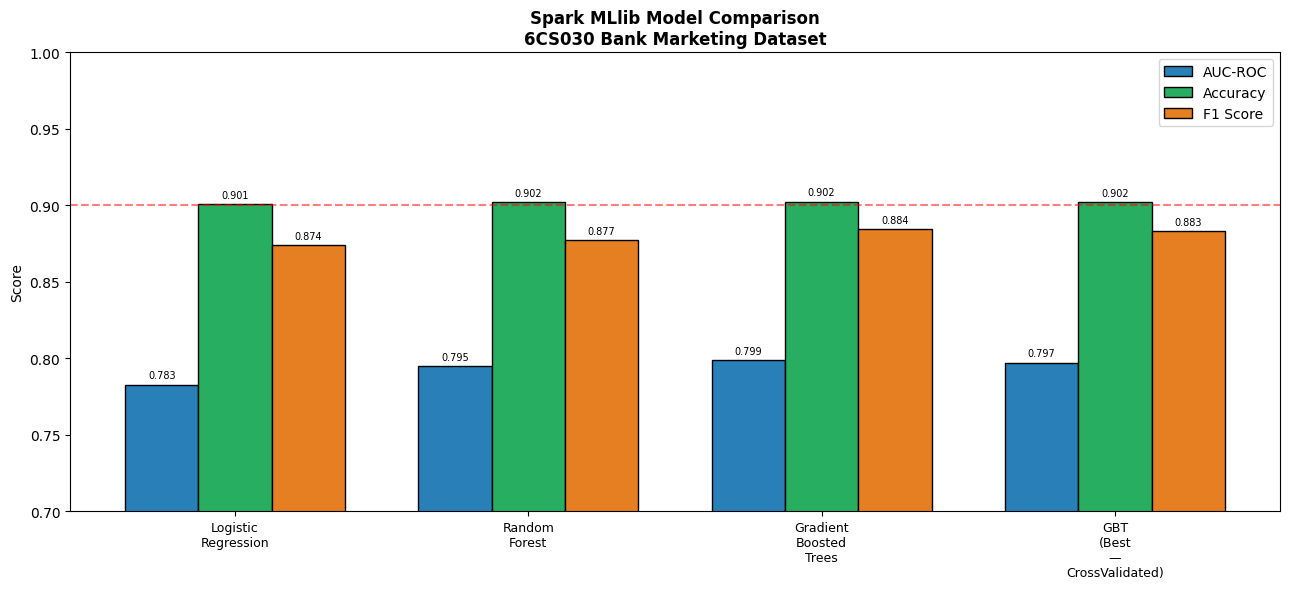

Model comparison saved as 'model_comparison.png'


In [ ]:
# Final comparison plot
all_metrics = [lr_metrics, rf_metrics, gbt_metrics, best_metrics]
model_names = [m['model'] for m in all_metrics]
auc_scores  = [m['auc']   for m in all_metrics]
f1_scores   = [m['f1']    for m in all_metrics]
acc_scores  = [m['acc']   for m in all_metrics]

x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width, auc_scores, width, label='AUC-ROC', color='#2980b9', edgecolor='black')
bars2 = ax.bar(x,         acc_scores, width, label='Accuracy', color='#27ae60', edgecolor='black')
bars3 = ax.bar(x + width, f1_scores,  width, label='F1 Score', color='#e67e22', edgecolor='black')

ax.set_ylim(0.7, 1.0)
ax.set_xticks(x)
ax.set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=9)
ax.set_ylabel('Score')
ax.set_title('Spark MLlib Model Comparison\n6CS030 Bank Marketing Dataset', fontweight='bold')
ax.legend()
ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.5, label='0.90 threshold')

for bar in [bars1, bars2, bars3]:
    for b in bar:
        ax.annotate(f'{b.get_height():.3f}',
                    xy=(b.get_x() + b.get_width()/2, b.get_height()),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Model comparison saved as 'model_comparison.png'")

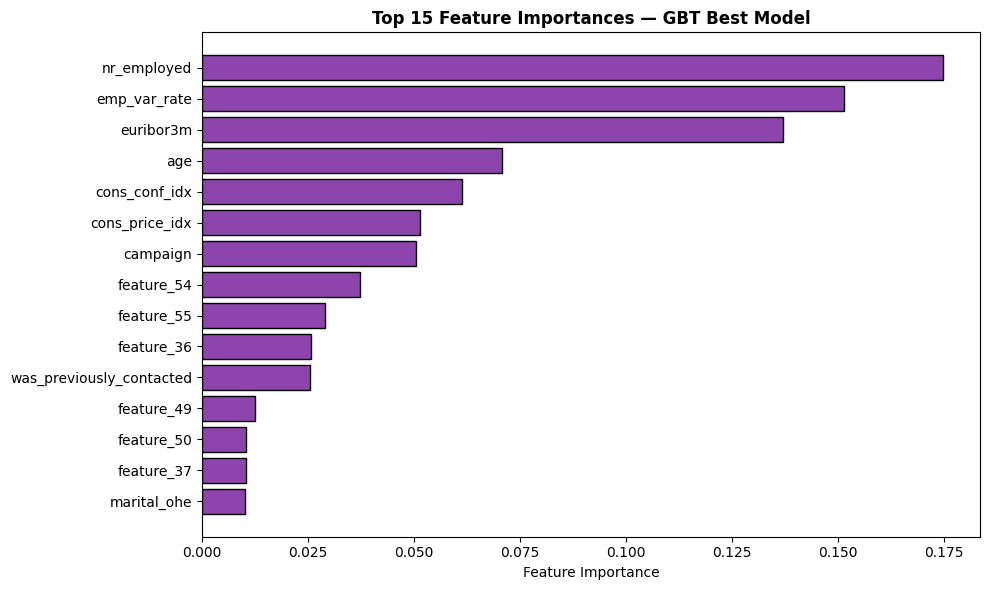

Feature importance chart saved.


In [ ]:
# Feature importances from best GBT
feature_names = numerical_cols + [c + "_ohe" for c in categorical_cols]
importances   = best_gbt.featureImportances.toArray()

# Only show top 15 features
top_n = min(15, len(importances))
top_idx  = np.argsort(importances)[::-1][:top_n]
top_imp  = importances[top_idx]
top_feat = [feature_names[i] if i < len(feature_names) else f"feature_{i}" for i in top_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_feat[::-1], top_imp[::-1], color='#8e44ad', edgecolor='black')
ax.set_xlabel('Feature Importance')
ax.set_title('Top 15 Feature Importances — GBT Best Model', fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance chart saved.")

---
## 10. Spark Execution Plan (DAG Inspection)

In [ ]:
# Show the physical/logical execution plan for the cleaning step
print("=== Logical Plan ===")
clean_df.explain(mode="simple")

=== Logical Plan ===
== Physical Plan ==
*(1) Project [age#17, CASE WHEN (job#18 = unknown) THEN admin. ELSE job#18 END AS job#499, CASE WHEN (marital#19 = unknown) THEN married ELSE marital#19 END AS marital#500, CASE WHEN (education#20 = unknown) THEN university.degree ELSE education#20 END AS education#501, CASE WHEN (default#21 = unknown) THEN no ELSE default#21 END AS credit_default#502, CASE WHEN (housing#22 = unknown) THEN yes ELSE housing#22 END AS housing#503, CASE WHEN (loan#23 = unknown) THEN no ELSE loan#23 END AS loan#504, contact#24, month#25, day_of_week#26, campaign#28, CASE WHEN (pdays#29 = 999) THEN 0 ELSE 1 END AS was_previously_contacted#506, previous#30, poutcome#31, emp.var.rate#32 AS emp_var_rate#508, cons.price.idx#33 AS cons_price_idx#509, cons.conf.idx#34 AS cons_conf_idx#510, euribor3m#35, nr.employed#36 AS nr_employed#512, CASE WHEN (y#37 = yes) THEN 1 ELSE 0 END AS label#513]
+- *(1) Filter (isnotnull(campaign#28) AND (campaign#28 <= 30))
   +- FileScan csv

In [ ]:
print("=== Extended Physical Plan ===")
clean_df.explain(mode="extended")

=== Extended Physical Plan ===
== Parsed Logical Plan ==
'Project [cast('age as int) AS age#498, CASE WHEN ('job = unknown) THEN admin. ELSE 'job END AS job#499, CASE WHEN ('marital = unknown) THEN married ELSE 'marital END AS marital#500, CASE WHEN ('education = unknown) THEN university.degree ELSE 'education END AS education#501, CASE WHEN ('default = unknown) THEN no ELSE 'default END AS credit_default#502, CASE WHEN ('housing = unknown) THEN yes ELSE 'housing END AS housing#503, CASE WHEN ('loan = unknown) THEN no ELSE 'loan END AS loan#504, 'contact, 'month, 'day_of_week, cast('campaign as int) AS campaign#505, CASE WHEN ('pdays = 999) THEN 0 ELSE 1 END AS was_previously_contacted#506, cast('previous as int) AS previous#507, 'poutcome, cast('`emp.var.rate` as double) AS emp_var_rate#508, cast('`cons.price.idx` as double) AS cons_price_idx#509, cast('`cons.conf.idx` as double) AS cons_conf_idx#510, cast('euribor3m as double) AS euribor3m#511, cast('`nr.employed` as double) AS nr_em

In [ ]:
# Spark partition info
print(f"Number of partitions (train_df) : {train_df.rdd.getNumPartitions()}")
print(f"Number of partitions (test_df)  : {test_df.rdd.getNumPartitions()}")
print(f"\nSpark Web UI for DAG visualization: {spark.sparkContext.uiWebUrl}")

Number of partitions (train_df) : 2
Number of partitions (test_df)  : 2

Spark Web UI for DAG visualization: http://4e50286d7546:4040


---
## 11. Session Summary & Stop

In [ ]:
print("\n" + "="*50)
print(" 6CS030 BIG DATA PROJECT — RESULTS SUMMARY")
print("="*50)
print(f"  Dataset        : Bank Marketing Additional (UCI)")
print(f"  Total records  : {clean_df.count():,}")
print(f"  Feature count  : {len(numerical_cols) + len(categorical_cols)}")
print(f"\n  --- Model Performance (Test Set) ---")
for m in all_metrics:
    print(f"  {m['model']:<35} AUC={m['auc']:.4f}  F1={m['f1']:.4f}  Acc={m['acc']:.4f}")
best = max(all_metrics, key=lambda x: x['auc'])
print(f"\n  Best Model     : {best['model']}")
print(f"  Best AUC-ROC   : {best['auc']:.4f}")
print("="*50)

spark.stop()
print("SparkSession stopped.")


 6CS030 BIG DATA PROJECT — RESULTS SUMMARY
  Dataset        : Bank Marketing Additional (UCI)
  Total records  : 41,155
  Feature count  : 19

  --- Model Performance (Test Set) ---
  Logistic Regression                 AUC=0.7828  F1=0.8738  Acc=0.9008
  Random Forest                       AUC=0.7947  F1=0.8770  Acc=0.9019
  Gradient Boosted Trees              AUC=0.7990  F1=0.8842  Acc=0.9024
  GBT (Best — CrossValidated)         AUC=0.7971  F1=0.8829  Acc=0.9023

  Best Model     : Gradient Boosted Trees
  Best AUC-ROC   : 0.7990
SparkSession stopped.
